# Model Evaluation (SVM vs DistilBERT)

This notebook evaluates a saved Linear SVM baseline and a fine-tuned DistilBERT model on the same balanced dataset and the same 80/20 stratified split.

Evaluation metrics:
- Accuracy
- Macro-averaged F1-score

Outputs:
- Classification reports
- Confusion matrices
- A comparison summary table saved to `results/model_comparison_summary.csv`

In [42]:
# Imports
import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

## 1. Dataset Loading & Model Loading

The cleaned and balanced dataset used during training is loaded.  
The dataset is expected to contain review text and corresponding sentiment labels.

In [43]:
# Paths and configuration

DATA_PATH = Path("../data/balanced_reviews.csv")

SVM_MODEL_PATH = Path("../models/svm_baseline/linear_svm.joblib")
SVM_VECT_PATH  = Path("../models/svm_baseline/tfidf_vectorizer.joblib")

DISTILBERT_DIR = Path("../models/distilbert_sentiment")
LABEL_MAP_PATH = DISTILBERT_DIR / "label_map.json"

RANDOM_STATE = 42
TEST_SIZE = 0.2

BATCH_SIZE = 32
MAX_LENGTH = 128

In [44]:
# Load dataset

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (120000, 2)


,Text,Sentiment
0,"i have an absolute passion for deep, dark hot ...",negative
1,"this drink is so ""super energy"" it's almost fr...",negative
2,"i'm sticking with what used to be carnation, n...",negative
3,aspertame causes alot of problems including pr...,negative
4,i ordered these because my local pet store sto...,negative


## 2. Feature and Label Selection

The text column and sentiment label column are defined below.  
If the dataset uses different column names, they should be updated accordingly.

In [45]:
# Inspect column names
print("Columns:")
print(df.columns.tolist())

# Attempt automatic detection
text_candidates = ["text", "review", "review_text", "content", "Text", "ReviewText"]
label_candidates = ["sentiment", "label", "Sentiment", "Label", "target", "class"]

def pick_column(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

TEXT_COL = pick_column(text_candidates, df.columns)
LABEL_COL = pick_column(label_candidates, df.columns)

print("Detected TEXT_COL:", TEXT_COL)
print("Detected LABEL_COL:", LABEL_COL)

Columns:
['Text', 'Sentiment']
Detected TEXT_COL: Text
Detected LABEL_COL: Sentiment


In [46]:
# Set column names explicitly
TEXT_COL = "Text"
LABEL_COL = "Sentiment"

# Basic validation
df = df[[TEXT_COL, LABEL_COL]].copy()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Missing text rows:", df[TEXT_COL].isna().sum())
print("Missing label rows:", df[LABEL_COL].isna().sum())

# Normalise label strings to lowercase and strip whitespace
df[LABEL_COL] = df[LABEL_COL].str.strip().str.lower() 

print("\nUnique labels after normalisation:")
print(sorted(df[LABEL_COL].unique()))

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())

Missing text rows: 0
Missing label rows: 0

Unique labels after normalisation:
['negative', 'neutral', 'positive']

Label distribution:
Sentiment
negative    40000
neutral     40000
positive    40000
Name: count, dtype: int64


## 3. Stratified Train-Test Split

An 80/20 train-test split is recreated using stratification and a fixed random state of 42.  
This ensures consistency with the experimental design described in the methodology.

In [47]:
X = df[TEXT_COL].values
y = df[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts())

Train size: 96000
Test size: 24000

Train distribution:
positive    32000
neutral     32000
negative    32000
Name: count, dtype: int64

Test distribution:
neutral     8000
positive    8000
negative    8000
Name: count, dtype: int64


## 4. Evaluation Functions

The following helper functions standardise metric computation and confusion matrix visualisation across both models.

In [59]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("Macro F1:", round(macro_f1, 4))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["negative", "neutral", "positive"]
    )

    return acc, macro_f1, cm

In [70]:
def plot_confusion_matrix(cm, title):
    labels = ["negative", "neutral", "positive"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="crest",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 5. Support Vector Machine (SVM) Evaluation

The pre-trained TF-IDF vectoriser and LinearSVC model are loaded.  
Predictions are generated for the test set and evaluated using accuracy, macro F1-score, and confusion matrix analysis.


=== Linear SVM (TF-IDF) ===
Accuracy: 0.7636
Macro F1: 0.7632


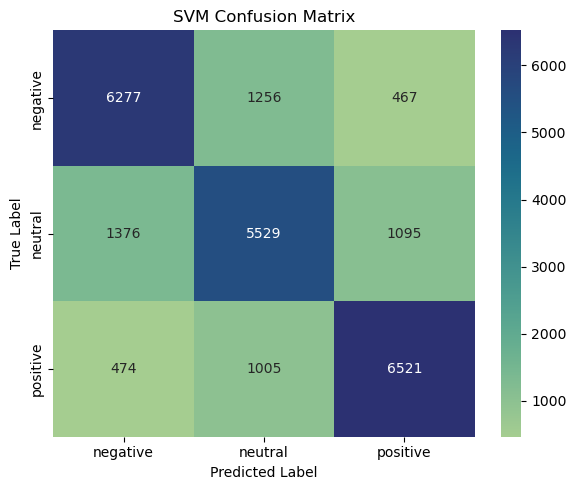

In [71]:
svm_acc, svm_macro_f1, svm_cm = evaluate_model(
    "Linear SVM (TF-IDF)",
    y_test,
    y_pred_svm
)

plot_confusion_matrix(svm_cm, "SVM Confusion Matrix")

## 6. DistilBERT Evaluation

The fine-tuned DistilBERT model is loaded and used to generate predictions on the same test set.

Logits produced by the model are converted to class predictions using the argmax function.  
Predicted class IDs are mapped to their corresponding sentiment labels.

### 6.1 Label Mapping

The saved label mapping is inspected to determine whether it maps class IDs to labels or labels to class IDs.  
The appropriate mapping direction is inferred automatically.

### 6.2 Batch Inference

Predictions are generated in batches to ensure computational efficiency.  
Each batch is tokenised, passed through the model, and converted to predicted class labels.

## 7. Comparative Performance Summary

The overall performance of both models is summarised in a comparison table including accuracy and macro-averaged F1-score.

## 8. Export of Results

The summary metrics are exported for use in Chapter 4 (Results) of the dissertation.